# **NCC presents:** Exploring PyEEG toolbox
---
Miranda Gonzales & Harish Dharshan | 01 JULY 2026

**To run this tutorial**, we will use the same dataset used in the original methods paper describing PyEEg toolbox (Bao, Liu & Zhang; 2011). This widely used dataset is known as the 2001 Bonn EEG time series dataset collected from healthy and epileptic human participants. See the following links & reference to learning more about this dataset:

Andrzejak, R. G., Lehnertz, K., Mormann, F., Rieke, C., David, P., & Elger, C. E. (2001). Indications of nonlinear deterministic and finite-dimensional structures in time series of brain electrical activity: Dependence on recording region and brain state. Physical Review E, 64(6), 061907. DOI: 10.1103/PhysRevE.64.061907.

**More information [here](https://github.com/UTSANeuroscienceCodingClub/central/blob/master/meetings/07-01-2026%20PyEEG%20Toolbox%3A%20Journal%20Club%20Discussion%20%26%20Code%20Tutorial/Start%20here.md)**


## Getting Started

In [ ]:
# To install directly into system, enter the following line of code into the terminal (Mac)...
# ---
# python -m pip install git+https://github.com/forrestbao/pyeeg.git

#####
# OR
#####

# To install in a specific virtual environment (conda):
# ---
# conda activate <virt-env>
# pip install git+https://github.com/forrestbao/pyeeg.git

In [2]:
# import relevant packages

import pyeeg

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import os


In [ ]:
# Example code from 2011 paper to load in a single text file from the described dataset

#fid_z001 = open('Z/Z001.txt', 'r')
#tmp_z001 = fid_z001.readlines()
#data_z001 = [float(k) for k in tmp_z001]
#print(len(data_z001))

In [8]:
# Useful functions to load datasets

def path_creator(participant, dir_):
    set_ = set_mapping[participant['set']]
    num = str(participant['num']).zfill(3)
  
    text_ = '.TXT' if participant['set'] == 'C' else '.txt'
    return (os.path.join(dir_, set_, set_ + num + text_))


def import_participant(participant, dir_):
    path_ = path_creator(participant, dir_)
    with open(path_, 'r') as f:
        data_ = [float(line.strip()) for line in f]

        return data_



In [ ]:
# Defining dataset directory and other parameters; Loading datasets 

# If all 'set' folders are located in the current working directory:
current_dir = os.getcwd()
print(f"Working in: {current_dir}")

# If all 'set' folders are located outside your current working directory, define the location directly...for example:
# dir_HD = r'C:\HarishDharshan\Programs\archive\Dataset' 


# Define how many text files you want to load per dataset (max 100)
desired_amount = 10

# Loading datasets into a list of dictionaries
set_mapping = {'A': 'Z',
               'B': 'O',
               'C': 'N',
               'D': 'F',
               'E': 'S'}

sets = ['A','B','C','D','E']

participants = [
    {'set': s, 'num': n}
    for s in sets
    for n in range(1,desired_amount+1)
]


for p in participants:
    p['data'] = import_participant(p, current_dir)
    #if p['num'] != 10:
    #    print(f'  loaded set {p['set']}, num {p['num']:>3d} :)')
    #else:
    #    print(f'  loaded set {p['set']}, num {p['num']:>3d} :3')

print(f"Loaded in {len(participants)} total channel datasets (across all 5 participants); each channel has {len(participants[0]['data'])} datapoints.")


Working in: C:\Users\Harish\Documents\Bonn Dataset
Loaded in 50 total channel datasets (across all 5 participants); each channel has 4097 datapoints.


Time between each data point: 0.00576 seconds.


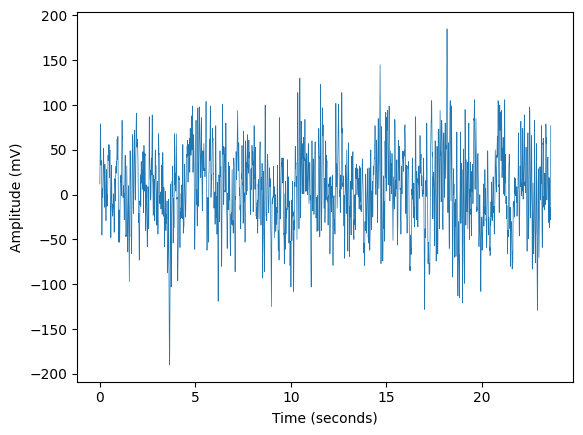

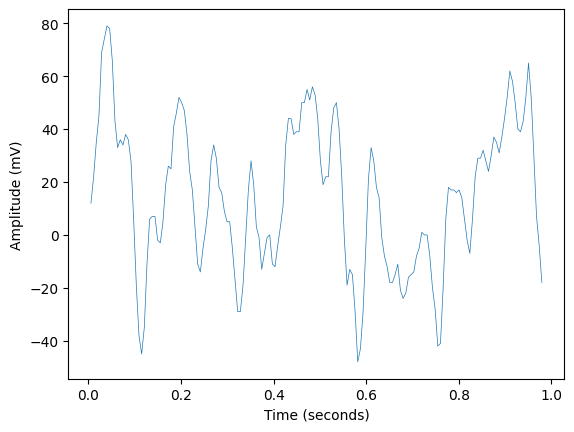

In [11]:
# Plots 0a & 0b: what is in our datasets?

# isolate one electrode channel in a participant dataset
data_A_001 = participants[0]['data']

# define the time points across the length of the recording (23.6 seconds)
dt_eeg = 23.6 / len(data_A_001)
print(f"Time between each data point: {dt_eeg:.5f} seconds.")
time_series = np.arange(0.00576, 23.6, 0.00576)

# full view
plt.plot(time_series, data_A_001, linewidth=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.show()

# zoomed in view
zoom_up_to = 170
plt.plot(time_series[:zoom_up_to], data_A_001[:zoom_up_to], linewidth=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.show()

## Available Features in PyEEG:

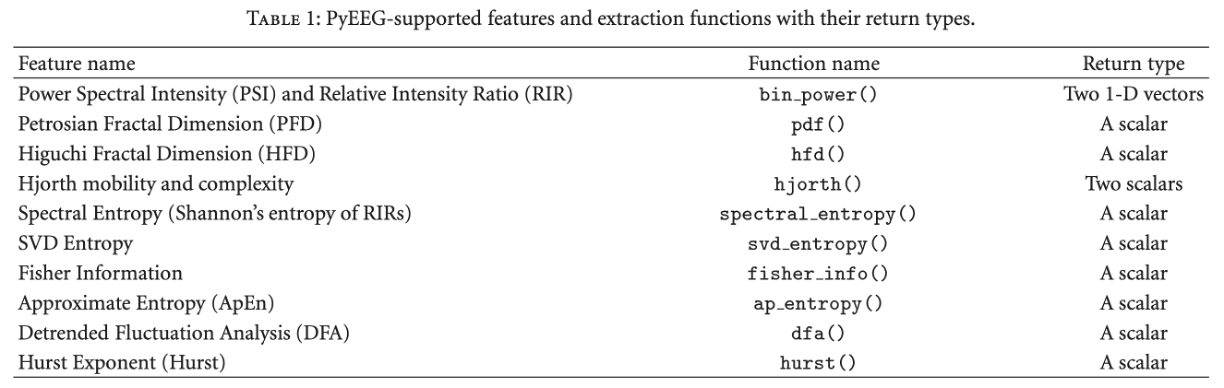

## **Feature 1:** Power Spectral Intensity (PSI) and Relative Intensity Ratio (RIR)
 Power Spectral analyses are a super well established way of analyzing EEG features. Basically, an EEG signal can be decompose into its constituent frequencies to see the relative intensities of each type of frequency, known as frequency bands. Think of how a slowly oscillating sinusoidal wave can have a much faster oscillation embedded within the same waveform:

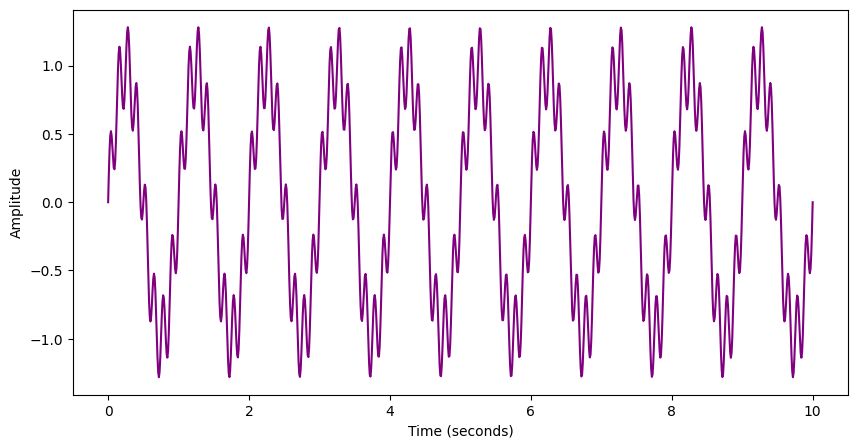

In [3]:
# Plot 1a: combined frequencies in a single waveform

# Generate time array (10 seconds, 1000 samples per second)
t = np.linspace(0, 10, 1000)

# Create a slow wave (e.g., 1 Hz) and a fast oscillation (e.g., 15 Hz)
slow_wave = np.sin(2 * np.pi * 1 * t)
fast_osc = 0.3 * np.sin(2 * np.pi * 8 * t)

# Combine them to show overlapping
combined = slow_wave + fast_osc

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t, combined, label='Combined Signal', color='purple')

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

In the above figure, we clearly see the two frequencies contributing to the overall signal. When we look at our EEG datasets, however, it is much more difficult to tell which frequencies are contributing to the recorded activity. Power spectral analyses typically use FFT-based (e.g. Fast Fourier Transform) algorithms to measure power at each frequency bin...there's TONS of cool litereature on this, so feel free to discuss this point and/or go read more if you're interested!
___
In PyEEG's first feature, **power spectral intensity (PSI)** performs FFT on the dataset of continuous (float) values using discrete bins. As a python user, you can decide where to set the boundaries of these bins. Like the article describes: 
>"Commonly used unequal bins are EEG/MEG rhythms, which are, δ (0.5–4 Hz), θ (4–8 Hz), α (8–12 Hz), β (12–30 Hz), and γ (30–100 Hz). For these bins, we have band = [0.5, 4, 8, 12, 30]."

......side note (MG), 8 Hz is the normal boundary in human data, not 7 Hz; the above quote is slightly editted to reflect this buuuut there's generally an open debate about where the boundaries should be exactly drawn........

The other described metric, **relative intensity ratio (RIR)**, essentially normalizes each band's PSI making different datasets more comparable.

---
So! If we go to the figure below, we will see what a continuous waveform ranging from 0 to 40 Hz looks like and the unequal representation of frequencies allocated to each band. When thinking about how these bands correlate to behavior, the slowest delta waves are most present during sleep while alpha is dominant during relaxed wake (faster activity in the beta & gamma range is correlated with intense focus, like when solving a tough coding problem;).

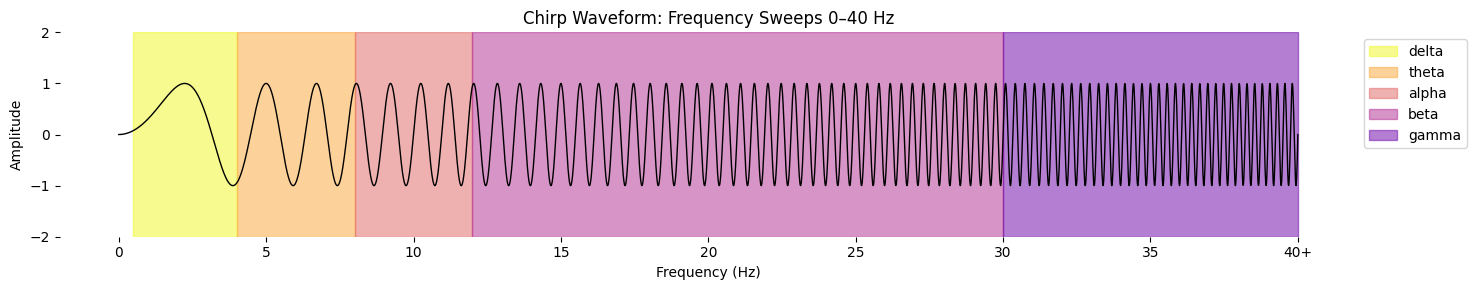

In [4]:
# Plot 1b: What are typical EEG/MEG band segments?

# Parameters
duration = 4.0          # seconds
sampling_rate = 1000    # Hz
t = np.linspace(0, duration, int(sampling_rate * duration))

# Generate chirp: sinusoid whose frequency increases from 0 to 40 Hz
max_freq = 40  # Hz
waveform = np.sin(2 * np.pi * (max_freq / (2 * duration)) * t**2)  # linear frequency sweep
wave_types = ['delta', 'theta', 'alpha', 'beta', 'gamma']
wave_type_bounds = [0.05,0.4,0.8,1.2,3.0,4.0]
plasma = cm['plasma'].resampled(6)

# Plot the waveform
plt.figure(figsize=(15, 3))
plt.plot(t, waveform, c='k', linewidth=1)

for i, w_type in enumerate(wave_types):
    plt.axvspan(wave_type_bounds[i], wave_type_bounds[i+1], color=plasma.colors[5-i], alpha=0.5, label=w_type)

plt.title("Chirp Waveform: Frequency Sweeps 0–40 Hz")
plt.xlabel("Frequency (Hz)")
plt.xticks([0,0.5,1,1.5,2,2.5,3,3.5,4],[0,5,10,15,20,25,30,35,'40+'])
plt.ylabel("Amplitude")
plt.ylim([-2,2])
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(False)
plt.box(False)
plt.tight_layout()
#plt.savefig("waveform_freqsweep_0to40Hz.pdf")
plt.show()


### *Using PSI function in PyEEG:*

In [5]:
help(pyeeg.bin_power)

Help on function bin_power in module pyeeg.spectrum:

bin_power(X, Band, Fs)
    Compute power in each frequency bin specified by Band from FFT result of
    X. By default, X is a real signal.

    Note
    -----
    A real signal can be synthesized, thus not real.

    Parameters
    -----------

    Band
        list

        boundary frequencies (in Hz) of bins. They can be unequal bins, e.g.
        [0.5,4,7,12,30] which are delta, theta, alpha and beta respectively.
        You can also use range() function of Python to generate equal bins and
        pass the generated list to this function.

        Each element of Band is a physical frequency and shall not exceed the
        Nyquist frequency, i.e., half of sampling frequency.

     X
        list

        a 1-D real time series.

    Fs
        integer

        the sampling rate in physical frequency

    Returns
    -------

    Power
        list

        spectral power in each frequency bin.

    Power_ratio
        list

 

In [6]:
# Parameters

# Define the sampling rate (see Table 2 in the paper):
f_s = 173

# Define your band boundaries:
bands = [0.5, 4, 8, 12, 30, 100]

# For more info on PSI and RIR: run the help function below:
# help(pyeeg.bin_power)

Example PSI:  [572100.4954961  467842.52331042 525901.62444589 762567.27683945
 273452.15160771]
Example ROI:  [0.21988101 0.17981052 0.20212494 0.29308498 0.10509855]


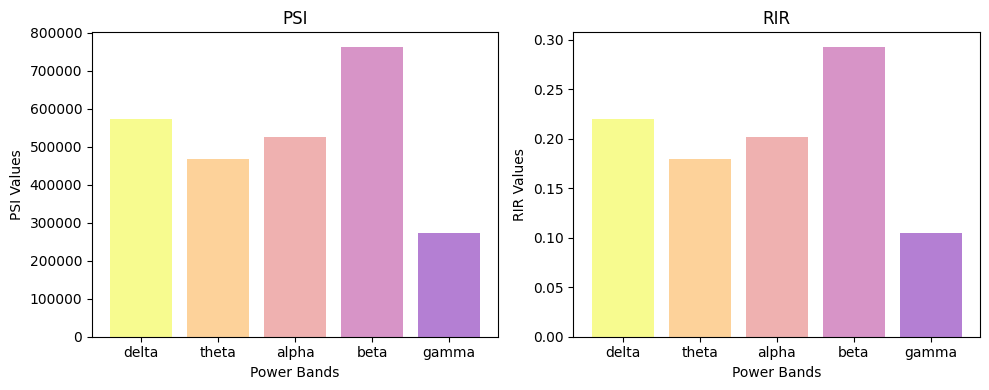

In [12]:
# Applying 5 bins to one channel from one participant; Plots 1c & 1d

roi_data = participants[0]['data']

roi_PSI, roi_RIR = pyeeg.bin_power(roi_data, bands, f_s)

print('Example PSI: ', roi_PSI)
print('Example ROI: ', roi_RIR)

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plasma_r = [plasma.colors[5-i] for i in range(5)]

# Plot the first bar graph
ax1.bar(wave_types, roi_PSI, color=plasma_r, alpha=0.5)
ax1.set_title('PSI')
ax1.set_xlabel('Power Bands')
ax1.set_ylabel('PSI Values')

# Plot the second bar graph
ax2.bar(wave_types, roi_RIR, color=plasma_r, alpha=0.5)
ax2.set_title('RIR')
ax2.set_xlabel('Power Bands')
ax2.set_ylabel('RIR Values')

# Optimize spacing and display
plt.tight_layout()
plt.show()

Another common way to visualize a power spectral analysis is with a power spectral density (PSD). This is very similar to Figure 3 in the article. The same PyEEG function is used but the band parameter is changed to capture much smaller, equal sized discrete ranges of frequencies.

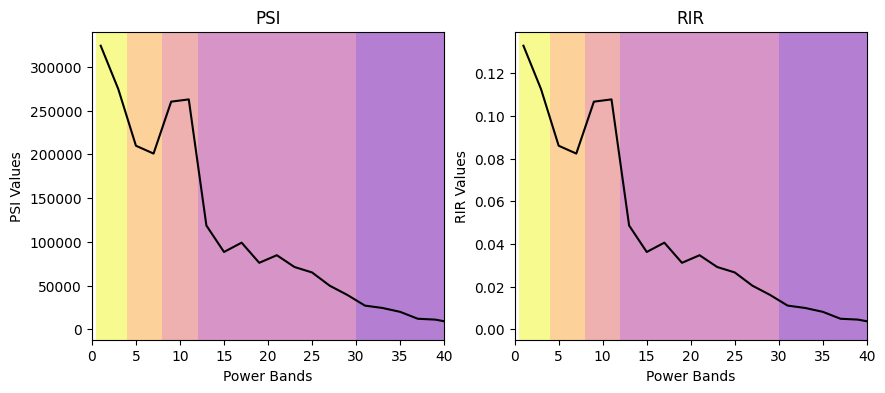

In [13]:
# Applying to 42 bins to one channel from one participant; Plots 1e & 1f

bands_alt = np.arange(1,86, 2) # try another set of bands! 
roi_PSI, roi_RIR = pyeeg.bin_power(roi_data, bands_alt, f_s)

#print('Example PSI: ', roi_PSI)
#print('Example ROI: ', roi_RIR)

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first lineplot 
ax1.plot(bands_alt[:-1], roi_PSI, color='black')
ax1.set_title('PSI')
ax1.set_xlabel('Power Bands')
ax1.set_ylabel('PSI Values')

# Plot the second lineplot
ax2.plot(bands_alt[:-1], roi_RIR, color='black')
ax2.set_title('RIR')
ax2.set_xlabel('Power Bands')
ax2.set_ylabel('RIR Values')

# Visualize the 5 typical EEG bands
for ax in [ax1, ax2]:
    for e, eeg_band in enumerate(wave_types):
        ax.axvspan(bands[e], bands[e+1], facecolor=plasma_r[e], alpha=0.5)

ax1.set_xlim(0,40)
ax2.set_xlim(0,40)
plt.show()


In [ ]:
# Coding challenge 1: recreate Figure 3
# Goal - visualize all 100 channels of data per participant by averaging each bin

# Discussion - what differences emerge in the delta, theta, alpha, beta, and gamma regions across participants?


## **Feature 2:** Hjorth mobility and flexibility
(Bo) Hjorth (of Swedish research in the 1970s) devised this method to analyze EEG signals using simple statistics - no FFT, no embedding, no nothing (except stats, of course...and some calculus). Essentially, this method computes 3 parameters:
- Activity: PyEEg's unnamed first hero e.g. variance) -> How much is the signal moving?
- Mobility: think first derivative -> How fast is it moving?
- Complexity: upgrade to second derivative -> How irregular is the waveform shape?

In [ ]:
# For more info on PSI and RIR: run the help function below:
# help(pyeeg.hjorth)

roi_data = participants[20]['data']
roi_hjorth_mobl, roi_hjorth_flex = pyeeg.hjorth(roi_data)
print(roi_hjorth_mobl, roi_hjorth_flex)

### *Ok, but...how did they even calculate these two scalars?*

In [ ]:
# Coding Challenge 2: 

# Reproduce the statistics described in the paper (section 3.4)

# Getting started:
# First, calculate variance (they call it Activity TM)
# Second, Mobility = √( var(dx/dt) / var(x) )
### where the derivative is approximated as, dx/dt ≈ x[n+1] - x[n]
# Third, calculate Complexity = Mobility(dx/dt) / Mobility(x)

# Discussion:
# What does Mobility capture about the data compared to Flexibility?
# Compare & contrast the Hjorth approach of using simple statistics vs more complex approaches, like those seen in machine learning.


## **Feature 3:** SVD Entropy
Singular Value Decomposition (SVD) is powerful technique used in machine learning that captures the dimensionality and, thus, complexity of the evaluated signal. Calculating the SVD entropy ultimately gives a metric to see how variable the data is.

In [ ]:
# Parameters (Table 2)
tau = 4
d_E = 10

# For more info on PSI and RIR: run the help function below:
# help(pyeeg.svd_entropy)

roi_data = participants[10]['data']
roi_svd = pyeeg.svd_entropy(roi_data, tau, d_E)
print(roi_svd)

### *Ok, but...how (the heck) did they calculate this scalar?*

In [ ]:
# Step 0, go to their github and navigate until understanding is reached :)

# Step 1, build an embedding sequence
# Essentially, this turns the 1D time-series data into a 2D matrix:
roi_Y = pyeeg.embed_seq(roi_data, tau, d_E)

# Step 2, use the svd function built in numpy.
# SVD factorizes the trajectory matrix into 3 matrices: X = U · Σ · Vᵀ
# The matrix of interest, Σ, holds the singular values telling us how much variance is captured by each dimension.
roi_W = np.linalg.svd(roi_Y, compute_uv=0) # perform svd
roi_W /= sum(roi_W)  # normalize singular values
print(roi_W)

# Step 3, calculate entropy (Shannon's method):
roi_entropy = -1 * sum(roi_W * np.log(roi_W))
print(roi_entropy)

# Outcomes:
# Low SVD entropy = a few singular values dominate the subspace, meaning the activity is stereotyped/repetitive (low dimensionality)
# High SVD entropy = singular values are spread more evenly, meaning activity is more random/unpredictable (high dimensionality)

In [ ]:
# Coding Challenge 3:

# Visualize SVD entropy

# Discussion: why might a neuroscientist care about SVD entropy? what about a computer scientist?

# Consider:
### non-linearity of brain dynamics
### complexity of brain states <3
### noise inherent to EEG
### interactions across frequencies 
### clinical applications
### foundation of more complex analyses (like PCA)
### dynamical systems & information theory 
### madly respects temporal structure <3
### utility of compressed representations
### relating time and frequency domains

## End of Tutorial
___
## Happy Coding!